In [1]:
!pip install -q kaggle

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from collections import Counter

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rambhadrakumar","key":"d747c6c1f3f9ec8e9cdf38ae9bb4619b"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arifmpthesis/bioimlab-chromosome-data-set-for-classification
!unzip -q bioimlab-chromosome-data-set-for-classification.zip -d /content/BioImLab

Dataset URL: https://www.kaggle.com/datasets/arifmpthesis/bioimlab-chromosome-data-set-for-classification
License(s): other
100% 10.7M/10.7M [00:00<00:00, 63.3MB/s]



In [5]:
import os

for root, dirs, files in os.walk("/content/BioImLab"):
    print(root, len(files))

/content/BioImLab 0
/content/BioImLab/Class_18 238
/content/BioImLab/Class_16 238
/content/BioImLab/Class_12 238
/content/BioImLab/Class_8 238
/content/BioImLab/Class_1 238
/content/BioImLab/Class_11 238
/content/BioImLab/Class_9 238
/content/BioImLab/Class_5 238
/content/BioImLab/Class_X 193
/content/BioImLab/Class_19 238
/content/BioImLab/Class_3 238
/content/BioImLab/Class_15 238
/content/BioImLab/Class_20 238
/content/BioImLab/Class_4 238
/content/BioImLab/Class_10 238
/content/BioImLab/Class_17 238
/content/BioImLab/Class_21 238
/content/BioImLab/Class_6 238
/content/BioImLab/Class_13 238
/content/BioImLab/Class_2 238
/content/BioImLab/Class_7 238
/content/BioImLab/Class_22 238
/content/BioImLab/Class_14 238
/content/BioImLab/Class_Y 45


In [6]:
import os

DATASET_DIR = "/content/BioImLab"

classes = sorted(
    [d for d in os.listdir(DATASET_DIR)
     if os.path.isdir(os.path.join(DATASET_DIR, d))],
    key=lambda x: (
        999 if x == "Class_X" else
        1000 if x == "Class_Y" else
        int(x.split("_")[1])
    )
)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 24
['Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Class_10', 'Class_11', 'Class_12', 'Class_13', 'Class_14', 'Class_15', 'Class_16', 'Class_17', 'Class_18', 'Class_19', 'Class_20', 'Class_21', 'Class_22', 'Class_X', 'Class_Y']


In [7]:
from collections import Counter

class_counts = {}

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".bmp", ".png", ".jpg", ".jpeg"))
    ]

    class_counts[cls] = len(images)

for cls, count in class_counts.items():
    print(f"{cls:10s} : {count}")

print("\nTotal images:", sum(class_counts.values()))

Class_1    : 238
Class_2    : 238
Class_3    : 238
Class_4    : 238
Class_5    : 238
Class_6    : 238
Class_7    : 238
Class_8    : 238
Class_9    : 238
Class_10   : 238
Class_11   : 238
Class_12   : 238
Class_13   : 238
Class_14   : 238
Class_15   : 238
Class_16   : 238
Class_17   : 238
Class_18   : 238
Class_19   : 238
Class_20   : 238
Class_21   : 238
Class_22   : 238
Class_X    : 193
Class_Y    : 45

Total images: 5474


In [8]:
from PIL import Image

dimension_counter = Counter()

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".bmp", ".png", ".jpg", ".jpeg")):

            path = os.path.join(folder, file)

            try:
                img = Image.open(path)
                dimension_counter[img.size] += 1
            except:
                pass

print("Different image dimensions:", len(dimension_counter))

for size, count in dimension_counter.most_common(20):
    print(size, ":", count)

Different image dimensions: 2051
(100, 200) : 1215
(31, 38) : 12
(39, 45) : 11
(41, 60) : 10
(37, 41) : 10
(42, 45) : 10
(30, 39) : 10
(39, 50) : 9
(29, 35) : 9
(34, 48) : 8
(42, 53) : 8
(34, 43) : 8
(33, 41) : 8
(39, 49) : 8
(37, 43) : 8
(37, 51) : 8
(37, 39) : 8
(34, 40) : 8
(29, 36) : 8
(33, 40) : 8


In [9]:
widths = []
heights = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)

    for file in os.listdir(folder):

        if file.lower().endswith((".bmp", ".png", ".jpg", ".jpeg")):

            path = os.path.join(folder, file)

            try:
                img = Image.open(path)

                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

print("Minimum width :", min(widths))
print("Maximum width :", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width : 13
Maximum width : 200
Minimum height: 15
Maximum height: 200


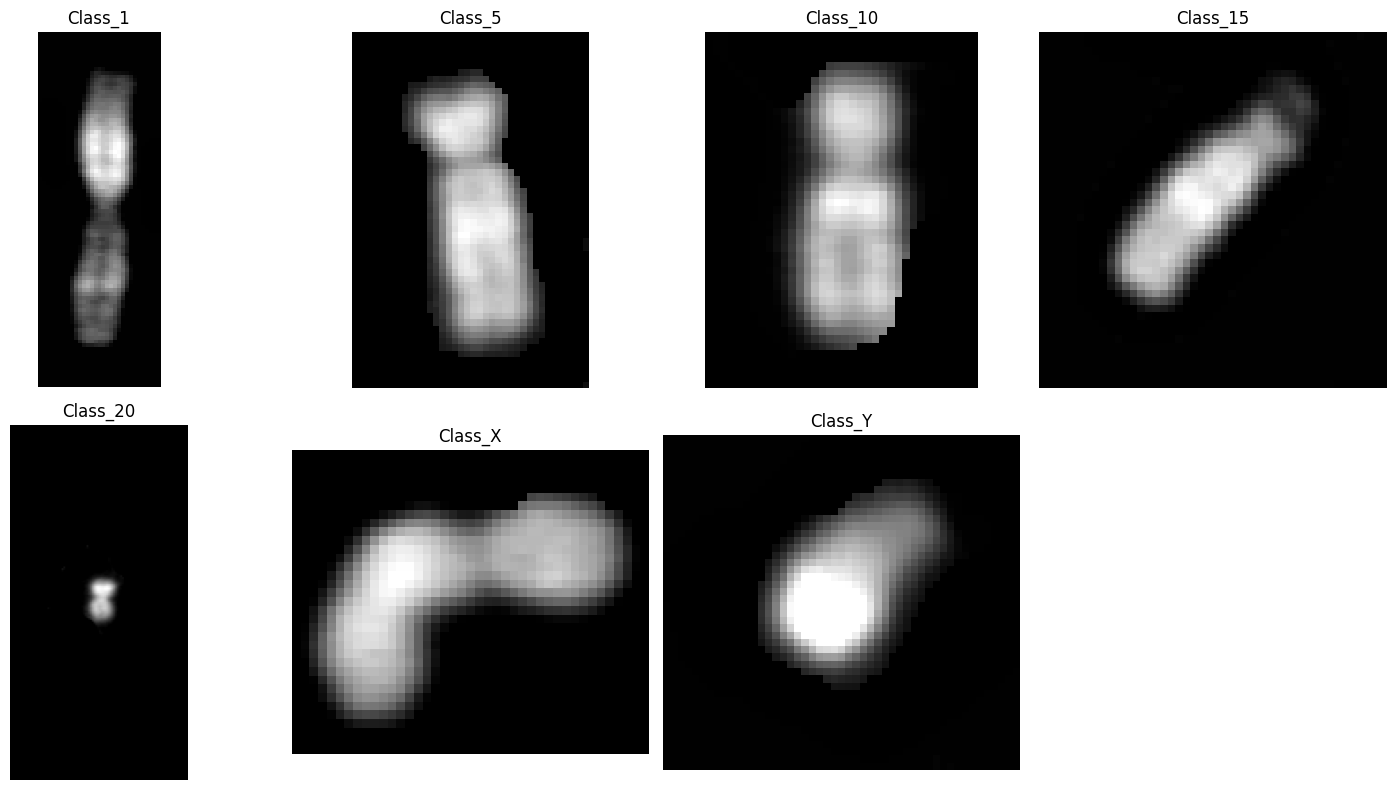

In [10]:
import random
import matplotlib.pyplot as plt
import cv2

sample_classes = [
    "Class_1",
    "Class_5",
    "Class_10",
    "Class_15",
    "Class_20",
    "Class_X",
    "Class_Y"
]

plt.figure(figsize=(15, 8))

for i, cls in enumerate(sample_classes):

    folder = os.path.join(DATASET_DIR, cls)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".bmp", ".png", ".jpg", ".jpeg"))
    ]

    file = random.choice(files)

    path = os.path.join(folder, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Analyse actual chroosome bounding box

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

def get_chromosome_bbox(image_path, threshold=10):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Find pixels belonging to the chromosome
    mask = img > threshold

    # Find coordinates
    coords = np.column_stack(np.where(mask))

    if len(coords) == 0:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return x_min, y_min, x_max, y_max

# Visualize the bounding box

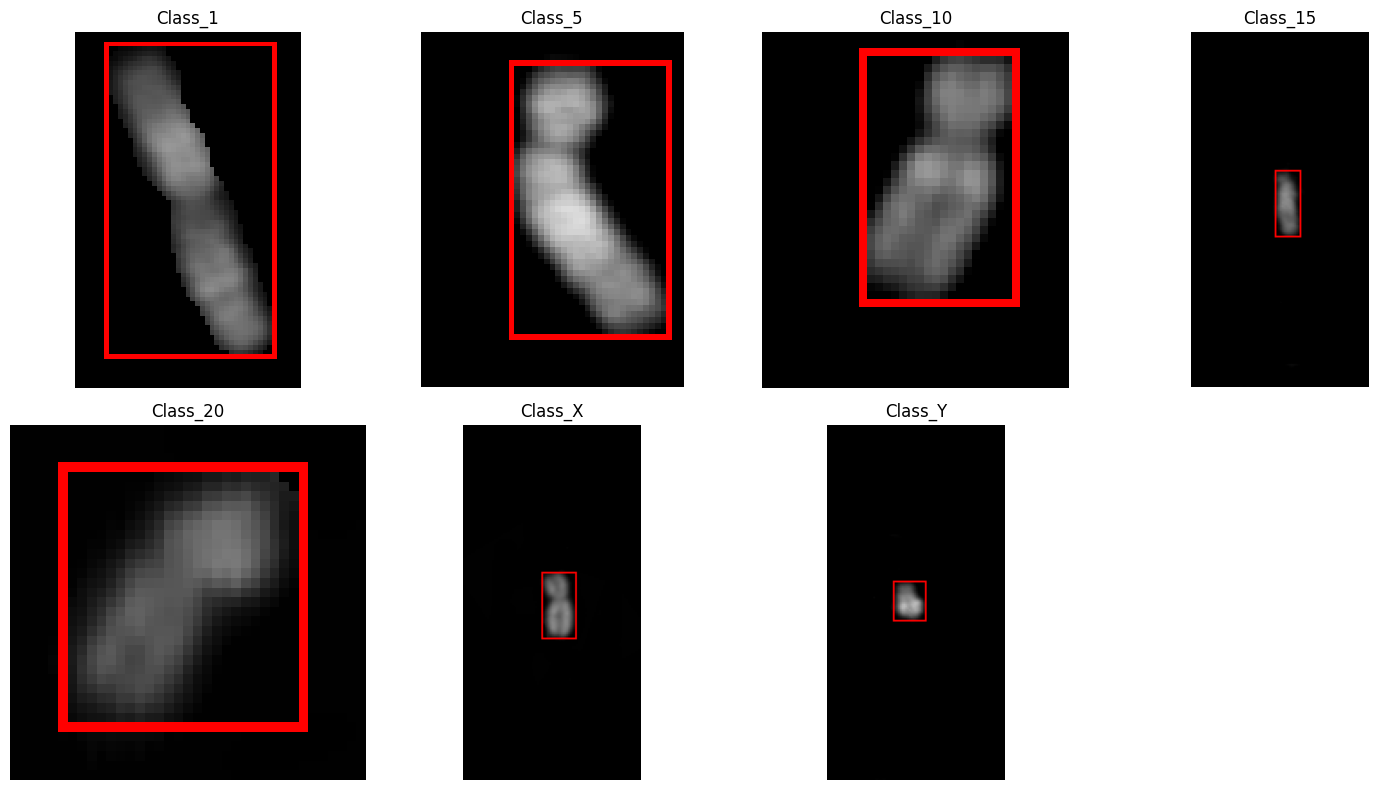

In [12]:
sample_classes = [
    "Class_1",
    "Class_5",
    "Class_10",
    "Class_15",
    "Class_20",
    "Class_X",
    "Class_Y"
]

plt.figure(figsize=(15, 8))

for i, cls in enumerate(sample_classes):

    folder = os.path.join(DATASET_DIR, cls)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".bmp", ".png", ".jpg", ".jpeg"))
    ]

    file = random.choice(files)
    path = os.path.join(folder, file)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    bbox = get_chromosome_bbox(path)

    if bbox is not None:

        x1, y1, x2, y2 = bbox

        display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        cv2.rectangle(
            display_img,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            1
        )

    else:
        display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(display_img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing function


In [16]:
def preprocess_chromosome(image_path, target_size=224):

    img = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        return None

    # Slight noise reduction
    blur = cv2.GaussianBlur(img, (3, 3), 0)

    # Otsu threshold
    _, mask = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Remove small noise
    kernel = np.ones((3, 3), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Connect nearby chromosome regions
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    if num_labels <= 1:
        return None

    # Ignore background (label 0)
    areas = stats[1:, cv2.CC_STAT_AREA]

    largest_idx = np.argmax(areas) + 1

    x = stats[largest_idx, cv2.CC_STAT_LEFT]
    y = stats[largest_idx, cv2.CC_STAT_TOP]
    w = stats[largest_idx, cv2.CC_STAT_WIDTH]
    h = stats[largest_idx, cv2.CC_STAT_HEIGHT]

    # Crop chromosome
    crop = img[
        y:y+h,
        x:x+w
    ]

    # Preserve aspect ratio
    crop_h, crop_w = crop.shape

    side = max(crop_h, crop_w)

    # Small padding around chromosome
    padding = max(2, int(side * 0.05))

    side = side + 2 * padding

    canvas = np.zeros(
        (side, side),
        dtype=np.uint8
    )

    y_offset = (side - crop_h) // 2
    x_offset = (side - crop_w) // 2

    canvas[
        y_offset:y_offset+crop_h,
        x_offset:x_offset+crop_w
    ] = crop

    # Resize
    canvas = cv2.resize(
        canvas,
        (target_size, target_size),
        interpolation=cv2.INTER_AREA
    )

    # Convert grayscale to RGB
    canvas = cv2.cvtColor(
        canvas,
        cv2.COLOR_GRAY2RGB
    )

    return canvas

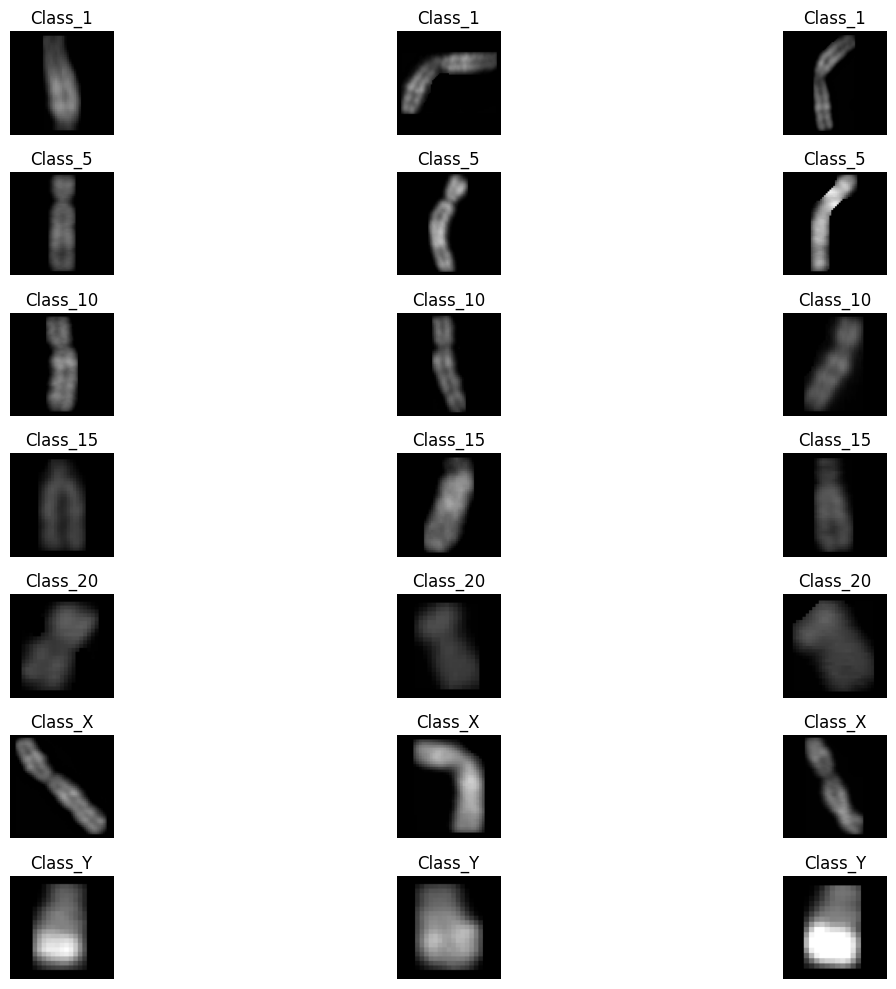

In [17]:
check_classes = [
    "Class_1",
    "Class_5",
    "Class_10",
    "Class_15",
    "Class_20",
    "Class_X",
    "Class_Y"
]

plt.figure(figsize=(14, 10))

plot_index = 1

for cls in check_classes:

    folder = os.path.join(DATASET_DIR, cls)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".bmp", ".png", ".jpg", ".jpeg")
        )
    ]

    selected = random.sample(
        files,
        min(3, len(files))
    )

    for file in selected:

        path = os.path.join(folder, file)

        processed = preprocess_chromosome(path)

        plt.subplot(7, 3, plot_index)

        if processed is not None:
            plt.imshow(processed)

        plt.title(cls)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

#Quantitative crop quality

In [18]:
# CELL 10 - Check crop dimensions and validity

import random
import numpy as np
import os

sample_count = 200

all_files = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".bmp", ".png", ".jpg", ".jpeg")):
            all_files.append((cls, os.path.join(folder, file)))

samples = random.sample(
    all_files,
    min(sample_count, len(all_files))
)

valid = 0
failed = 0

crop_heights = []
crop_widths = []

for cls, path in samples:

    processed = preprocess_chromosome(path)

    if processed is None:
        failed += 1
        continue

    valid += 1

    # processed should always be 224 x 224 x 3
    assert processed.shape == (224, 224, 3)

print("Images checked :", len(samples))
print("Valid          :", valid)
print("Failed         :", failed)
print("Output shape   :", processed.shape)

Images checked : 200
Valid          : 200
Failed         : 0
Output shape   : (224, 224, 3)


#Visual check

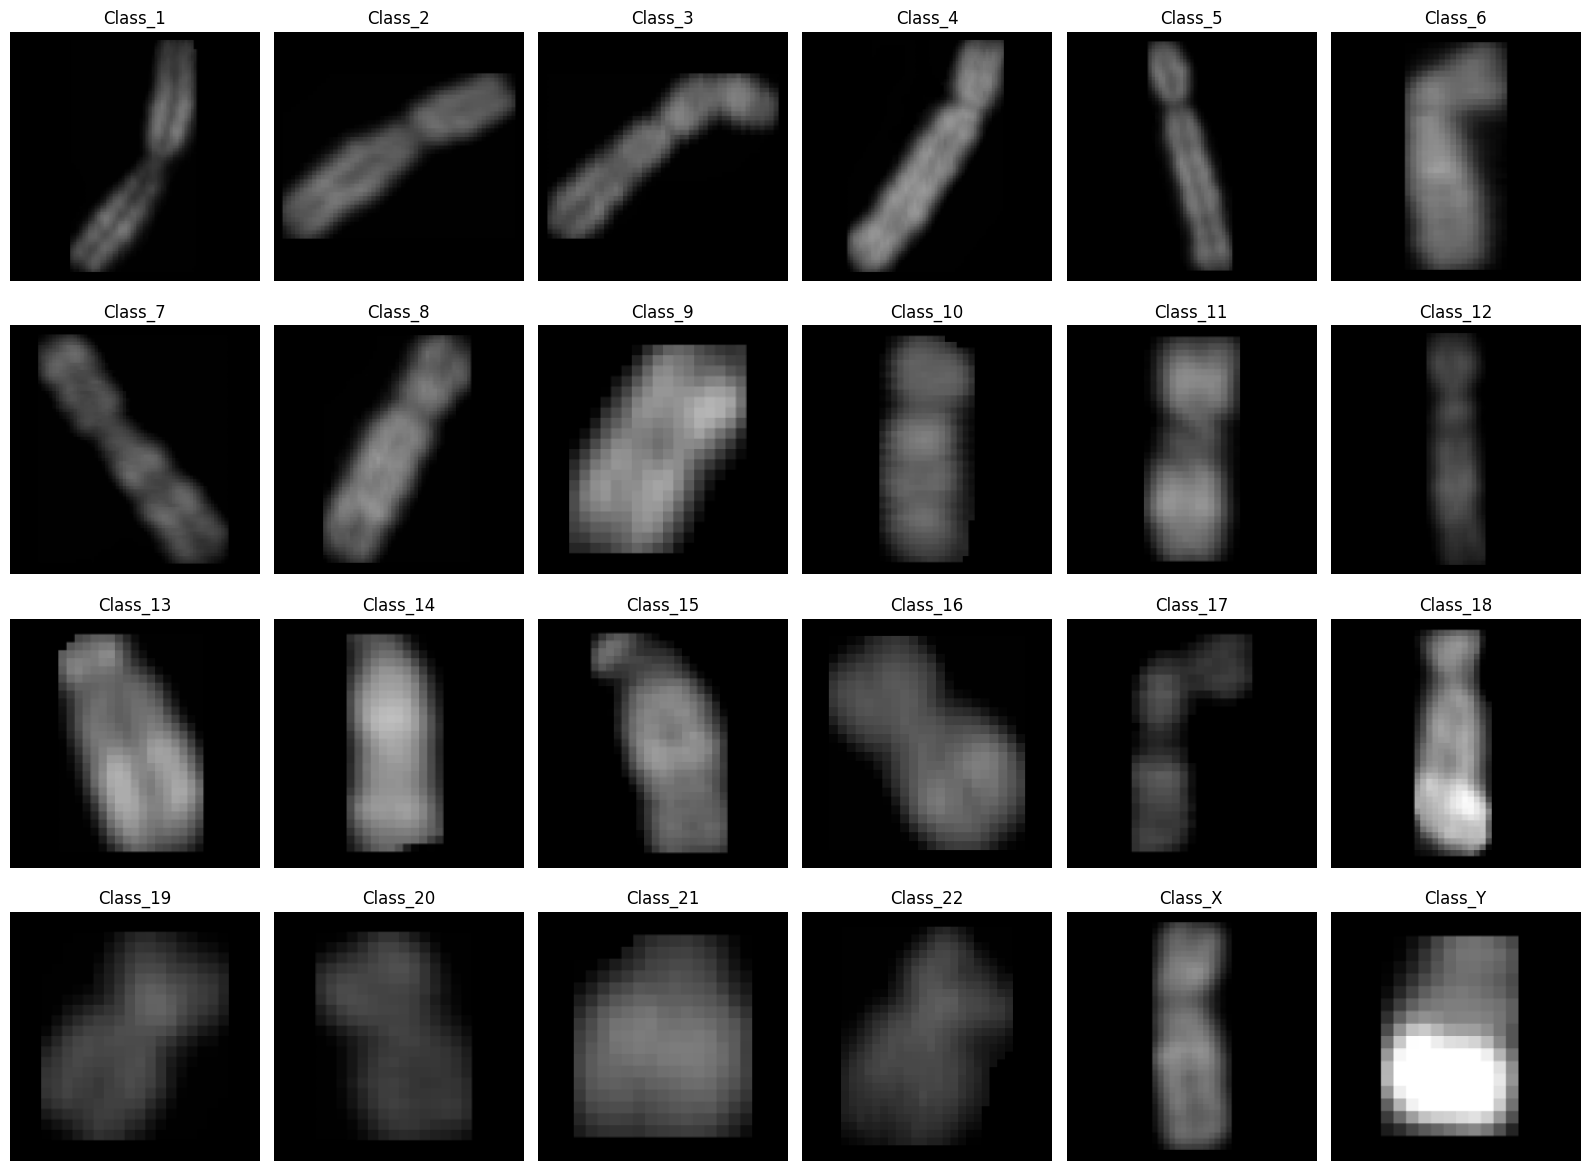

In [19]:
# CELL 11 - One processed image from every chromosome class

plt.figure(figsize=(16, 12))

for i, cls in enumerate(classes):

    folder = os.path.join(DATASET_DIR, cls)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".bmp", ".png", ".jpg", ".jpeg")
        )
    ]

    file = random.choice(files)

    path = os.path.join(folder, file)

    processed = preprocess_chromosome(path)

    plt.subplot(4, 6, i + 1)
    plt.imshow(processed)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Complete processed dataset

In [20]:
# CELL 12 - Create complete processed dataset

PROCESSED_DIR = "/content/BioImLab_Processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

total = 0
failed = 0

for cls in classes:

    input_folder = os.path.join(DATASET_DIR, cls)
    output_folder = os.path.join(PROCESSED_DIR, cls)

    os.makedirs(output_folder, exist_ok=True)

    files = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith(
            (".bmp", ".png", ".jpg", ".jpeg")
        )
    ]

    for file in files:

        input_path = os.path.join(
            input_folder,
            file
        )

        output_path = os.path.join(
            output_folder,
            os.path.splitext(file)[0] + ".png"
        )

        processed = preprocess_chromosome(
            input_path,
            target_size=224
        )

        if processed is None:
            failed += 1
            continue

        # Convert RGB back to grayscale for storage
        gray = cv2.cvtColor(
            processed,
            cv2.COLOR_RGB2GRAY
        )

        cv2.imwrite(
            output_path,
            gray
        )

        total += 1

print("Processing complete")
print("Processed images :", total)
print("Failed images    :", failed)
print("Output directory :", PROCESSED_DIR)

Processing complete
Processed images : 5474
Failed images    : 0
Output directory : /content/BioImLab_Processed


#Verifying dataset

In [21]:
# CELL 13 - Verify processed dataset

total_images = 0

print("Processed dataset:")
print("-" * 40)

for cls in classes:

    folder = os.path.join(
        PROCESSED_DIR,
        cls
    )

    files = [
        f for f in os.listdir(folder)
        if f.endswith(".png")
    ]

    print(f"{cls:10s} : {len(files)}")

    total_images += len(files)

print("-" * 40)
print("Total images :", total_images)

Processed dataset:
----------------------------------------
Class_1    : 238
Class_2    : 238
Class_3    : 238
Class_4    : 238
Class_5    : 238
Class_6    : 238
Class_7    : 238
Class_8    : 238
Class_9    : 238
Class_10   : 238
Class_11   : 238
Class_12   : 238
Class_13   : 238
Class_14   : 238
Class_15   : 238
Class_16   : 238
Class_17   : 238
Class_18   : 238
Class_19   : 238
Class_20   : 238
Class_21   : 238
Class_22   : 238
Class_X    : 193
Class_Y    : 45
----------------------------------------
Total images : 5474


#Verify actual dimension


In [22]:
# CELL 14 - Verify every processed image has the same size

wrong_size = []
total_checked = 0

for cls in classes:

    folder = os.path.join(
        PROCESSED_DIR,
        cls
    )

    for file in os.listdir(folder):

        if not file.endswith(".png"):
            continue

        path = os.path.join(folder, file)

        img = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        total_checked += 1

        if img is None:
            wrong_size.append(
                (cls, file, "Unreadable")
            )

        elif img.shape != (224, 224):
            wrong_size.append(
                (cls, file, img.shape)
            )

print("Images checked :", total_checked)
print("Wrong size     :", len(wrong_size))

if len(wrong_size) > 0:
    print("\nExamples:")
    print(wrong_size[:10])
else:
    print("All images are exactly 224 x 224")

Images checked : 5474
Wrong size     : 0
All images are exactly 224 x 224


#Train test validate split

In [23]:
# CELL 15 - Create stratified train/validation/test split

from sklearn.model_selection import train_test_split

image_paths = []
image_labels = []

for cls in classes:

    folder = os.path.join(
        PROCESSED_DIR,
        cls
    )

    for file in os.listdir(folder):

        if not file.endswith(".png"):
            continue

        image_paths.append(
            os.path.join(folder, file)
        )

        image_labels.append(cls)

print("Total images :", len(image_paths))
print("Total labels :", len(image_labels))
print("Classes      :", len(set(image_labels)))

Total images : 5474
Total labels : 5474
Classes      : 24


#Stratified split

In [24]:
# CELL 16 - Stratified train/validation/test split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.30,
    random_state=42,
    stratify=image_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training images   :", len(train_paths))
print("Validation images :", len(val_paths))
print("Test images       :", len(test_paths))

Training images   : 3831
Validation images : 821
Test images       : 822


#Verify class distribution

In [25]:
# CELL 17 - Verify class distribution

from collections import Counter

train_count = Counter(train_labels)
val_count = Counter(val_labels)
test_count = Counter(test_labels)

print(
    f"{'Class':<10}"
    f"{'Train':>10}"
    f"{'Val':>10}"
    f"{'Test':>10}"
)

print("-" * 40)

for cls in classes:

    print(
        f"{cls:<10}"
        f"{train_count[cls]:>10}"
        f"{val_count[cls]:>10}"
        f"{test_count[cls]:>10}"
    )

Class          Train       Val      Test
----------------------------------------
Class_1          167        36        35
Class_2          167        35        36
Class_3          167        36        35
Class_4          166        36        36
Class_5          167        35        36
Class_6          167        36        35
Class_7          166        36        36
Class_8          167        35        36
Class_9          166        36        36
Class_10         167        36        35
Class_11         166        36        36
Class_12         167        35        36
Class_13         167        35        36
Class_14         167        35        36
Class_15         166        36        36
Class_16         166        36        36
Class_17         167        36        35
Class_18         166        36        36
Class_19         166        36        36
Class_20         167        35        36
Class_21         167        36        35
Class_22         166        36        36
Class_X         

#Tensorflow input pipelies(datsets)

In [27]:
# CELL 18 - Create TensorFlow datasets

import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 24

# Convert class names to integer labels
class_to_index = {
    cls: i for i, cls in enumerate(classes)
}

train_y = np.array([
    class_to_index[label] for label in train_labels
])

val_y = np.array([
    class_to_index[label] for label in val_labels
])

test_y = np.array([
    class_to_index[label] for label in test_labels
])

print("Class mapping:")
for cls, idx in class_to_index.items():
    print(idx, "->", cls)

Class mapping:
0 -> Class_1
1 -> Class_2
2 -> Class_3
3 -> Class_4
4 -> Class_5
5 -> Class_6
6 -> Class_7
7 -> Class_8
8 -> Class_9
9 -> Class_10
10 -> Class_11
11 -> Class_12
12 -> Class_13
13 -> Class_14
14 -> Class_15
15 -> Class_16
16 -> Class_17
17 -> Class_18
18 -> Class_19
19 -> Class_20
20 -> Class_21
21 -> Class_22
22 -> Class_X
23 -> Class_Y


#Image loading function

In [45]:
# CELL 19 - Final image loading function

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Grayscale -> RGB
    image = tf.image.grayscale_to_rgb(image)

    # Normalize pixels from [0,255] to [0,1]
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

#Building tensorflow datasets

In [29]:
# CELL 20 - Build TensorFlow datasets

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_y)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_y)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_y)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(
    1000,
    seed=42
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


#verifu actual batch

In [30]:
# CELL 21 - Verify input batch

images, labels = next(iter(train_ds))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image dtype       :", images.dtype)
print("Image min         :", tf.reduce_min(images).numpy())
print("Image max         :", tf.reduce_max(images).numpy())
print("Labels            :", labels.numpy()[:10])

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Image dtype       : <dtype: 'float32'>
Image min         : 0.0
Image max         : 253.0
Labels            : [16 12  3 17 18  6 11 23  3  7]


#Visualizing model input

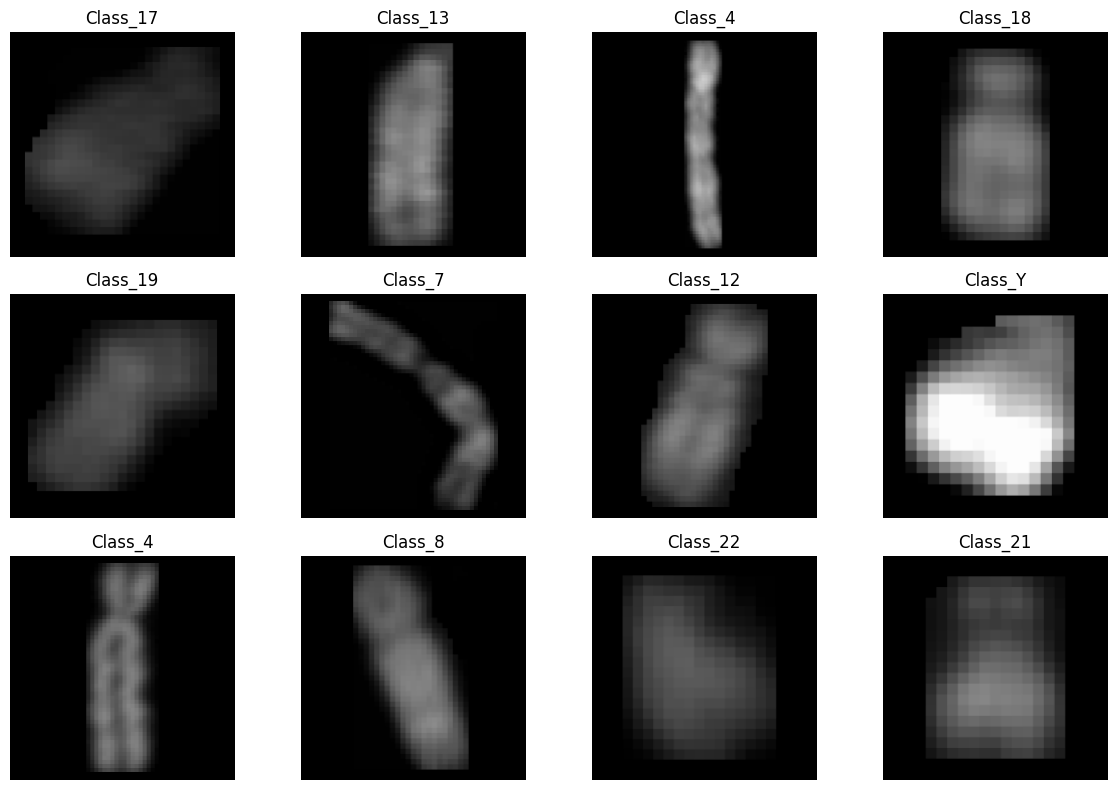

In [31]:
# CELL 22 - Visualize training batch

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        images[i].numpy().astype(np.uint8)
    )

    plt.title(
        classes[labels[i].numpy()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#Training augmentation

In [52]:
# CELL 23 - Augmentation for visualization

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.03, 0.03),
        width_factor=(-0.03, 0.03)
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.02,
        width_factor=0.02
    )
])

print("Augmentation created successfully.")

Augmentation created successfully.


#Test Augmentation

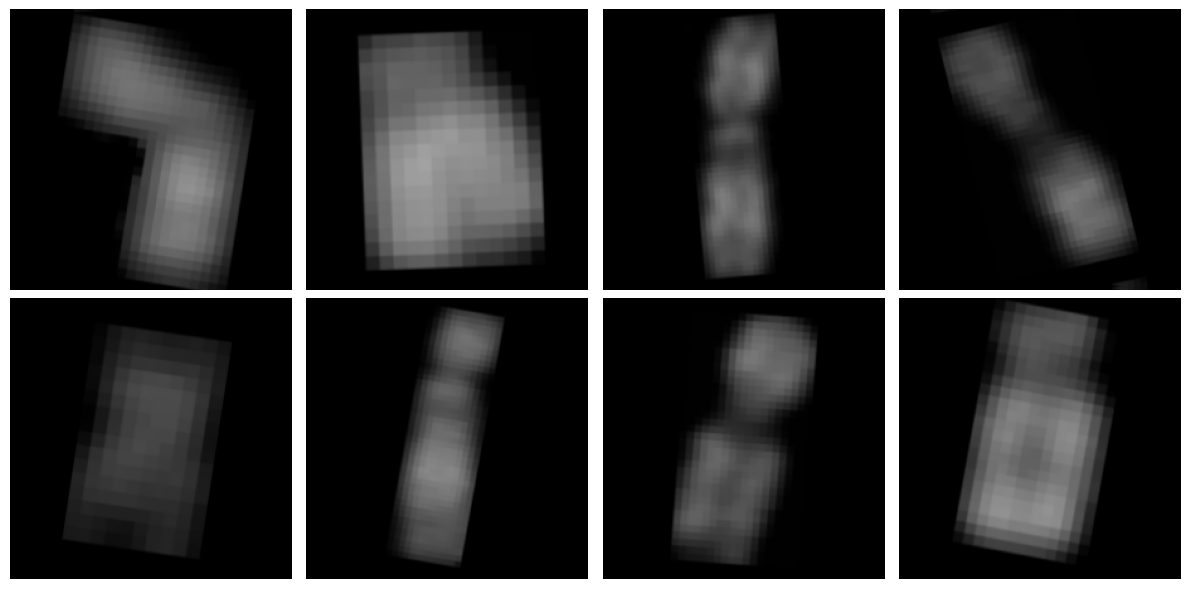

In [54]:
# CELL 24 - Visualize augmentation

# Take images directly from the existing training paths
sample_paths = train_paths[:8]

sample_images = []

for path in sample_paths:

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.image.grayscale_to_rgb(image)

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    sample_images.append(image)

sample_images = tf.stack(sample_images)

# Apply augmentation ONCE
augmented_images = data_augmentation(
    sample_images,
    training=True
)

plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        augmented_images[i].numpy()
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#Class weights

In [55]:
print("Number of classes:", len(classes))
print("Number of training labels:", len(train_labels))

print("\nEncoded labels:")
print(np.unique(train_labels_encoded))

print("\nClass weights:")
print(class_weights)

Number of classes: 24
Number of training labels: 3831

Encoded labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Class weights:
{0: np.float64(0.9558383233532934), 1: np.float64(0.9558383233532934), 2: np.float64(0.9558383233532934), 3: np.float64(0.9615963855421686), 4: np.float64(0.9558383233532934), 5: np.float64(0.9558383233532934), 6: np.float64(0.9615963855421686), 7: np.float64(0.9558383233532934), 8: np.float64(0.9615963855421686), 9: np.float64(0.9558383233532934), 10: np.float64(0.9615963855421686), 11: np.float64(0.9558383233532934), 12: np.float64(0.9558383233532934), 13: np.float64(0.9558383233532934), 14: np.float64(0.9615963855421686), 15: np.float64(0.9615963855421686), 16: np.float64(0.9558383233532934), 17: np.float64(0.9615963855421686), 18: np.float64(0.9615963855421686), 19: np.float64(0.9558383233532934), 20: np.float64(0.9558383233532934), 21: np.float64(0.9615963855421686), 22: np.float64(1.1824074074074074), 23: np.float64(5.149

In [56]:
# CELL 25 - Calculate class weights correctly

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert class names to integer indices
class_to_index = {
    class_name: i
    for i, class_name in enumerate(classes)
}

train_labels_encoded = np.array([
    class_to_index[label]
    for label in train_labels
])

# Calculate balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_encoded
)

class_weights = {}

for i in range(NUM_CLASSES):
    class_weights[i] = class_weights_array[i]

print("Class weights:\n")

for i in range(NUM_CLASSES):
    print(
        f"{classes[i]:10s} : {class_weights[i]:.3f}"
    )

Class weights:

Class_1    : 0.956
Class_2    : 0.956
Class_3    : 0.956
Class_4    : 0.962
Class_5    : 0.956
Class_6    : 0.956
Class_7    : 0.962
Class_8    : 0.956
Class_9    : 0.962
Class_10   : 0.956
Class_11   : 0.962
Class_12   : 0.956
Class_13   : 0.956
Class_14   : 0.956
Class_15   : 0.962
Class_16   : 0.962
Class_17   : 0.956
Class_18   : 0.962
Class_19   : 0.962
Class_20   : 0.956
Class_21   : 0.956
Class_22   : 0.962
Class_X    : 1.182
Class_Y    : 5.149


#building resnet50 model

In [40]:
# CELL 26 - Build ResNet50 model

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model

IMG_SIZE = 224
NUM_CLASSES = 24

# Input
inputs = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Pretrained ResNet50 backbone
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

# Freeze backbone initially
base_model.trainable = False

# Classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

# Complete model
model = Model(
    inputs=inputs,
    outputs=outputs
)

print("ResNet50 model created successfully.")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model created successfully.
Input shape : (None, 224, 224, 3)
Output shape: (None, 24)


#Inspect the model

In [57]:
# CELL 27 - ResNet50 architecture and parameters

model.summary()

total_params = model.count_params()
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.trainable_weights
)
non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.non_trainable_weights
)

print("\n" + "="*50)
print("MODEL PARAMETER SUMMARY")
print("="*50)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Non-trainable        : {non_trainable_params:,}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,636,888 (90.17 MB)

 Trainable params: 49,176 (192.09 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


MODEL PARAMETER SUMMARY
Total parameters     : 23,636,888
Trainable parameters : 49,176
Non-trainable        : 23,587,712


#creating training and valodation pipelines

In [59]:
# CELL 28 - Final TensorFlow datasets

AUTOTUNE = tf.data.AUTOTUNE

# -------------------------
# TRAIN DATASET
# -------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_y)
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=42,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

# Batch BEFORE augmentation
train_ds = train_ds.batch(BATCH_SIZE)

# Apply augmentation to complete batches
train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(x, training=True),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)


# -------------------------
# VALIDATION DATASET
# -------------------------

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_y)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)

val_ds = val_ds.prefetch(AUTOTUNE)


# -------------------------
# TEST DATASET
# -------------------------

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_y)
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(AUTOTUNE)


print("Training images   :", len(train_paths))
print("Validation images :", len(val_paths))
print("Test images       :", len(test_paths))
print("Batch size        :", BATCH_SIZE)
print("Input size        :", IMG_SIZE)

Training images   : 3831
Validation images : 821
Test images       : 822
Batch size        : 32
Input size        : (224, 224)


#verify final pipeline

In [60]:
# CELL 29 - Verify final pipeline

images, labels = next(iter(train_ds))

print("Training batch")
print("-" * 40)

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Image dtype :", images.dtype)
print("Min value   :", tf.reduce_min(images).numpy())
print("Max value   :", tf.reduce_max(images).numpy())
print("Labels      :", labels.numpy()[:10])

Training batch
----------------------------------------
Image shape : (32, 224, 224, 3)
Label shape : (32,)
Image dtype : <dtype: 'float32'>
Min value   : 0.0
Max value   : 0.99215686
Labels      : [ 2 12 19 14 14 21  5  7 14 22]


#compile resnet50

In [61]:
# CELL 30 - Compile ResNet50

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Optimizer       : Adam")
print("Learning rate   : 0.001")
print("Loss            : Sparse Categorical Crossentropy")
print("Metric          : Accuracy")

Model compiled successfully.
Optimizer       : Adam
Learning rate   : 0.001
Loss            : Sparse Categorical Crossentropy
Metric          : Accuracy


#Training callbacks

In [62]:
# CELL 31 - Training callbacks

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    ReduceLROnPlateau,
    EarlyStopping
)

checkpoint_path = "/content/resnet50_stage1_best.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


#Training stage - 1

In [65]:
# CELL 32 - Stage 1 ResNet50 training

EPOCHS_STAGE1 = 15

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.0318 - loss: 3.3901
Epoch 1: val_accuracy improved from None to 0.04385, saving model to /content/resnet50_stage1_best.keras

Epoch 1: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 75s 490ms/step - accuracy: 0.0316 - loss: 3.3486 - val_accuracy: 0.0438 - val_loss: 3.2014 - learning_rate: 0.0010
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.0410 - loss: 3.2681
Epoch 2: val_accuracy did not improve from 0.04385
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 370ms/step - accuracy: 0.0389 - loss: 3.2762 - val_accuracy: 0.0195 - val_loss: 3.2036 - learning_rate: 0.0010
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.0359 - loss: 3.2423
Epoch 3: val_accuracy improved from 0.04385 to 0.05968, saving model to /content/resnet50_stage1_best.keras

Epoch 3: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 400ms/ste

KeyboardInterrupt: 

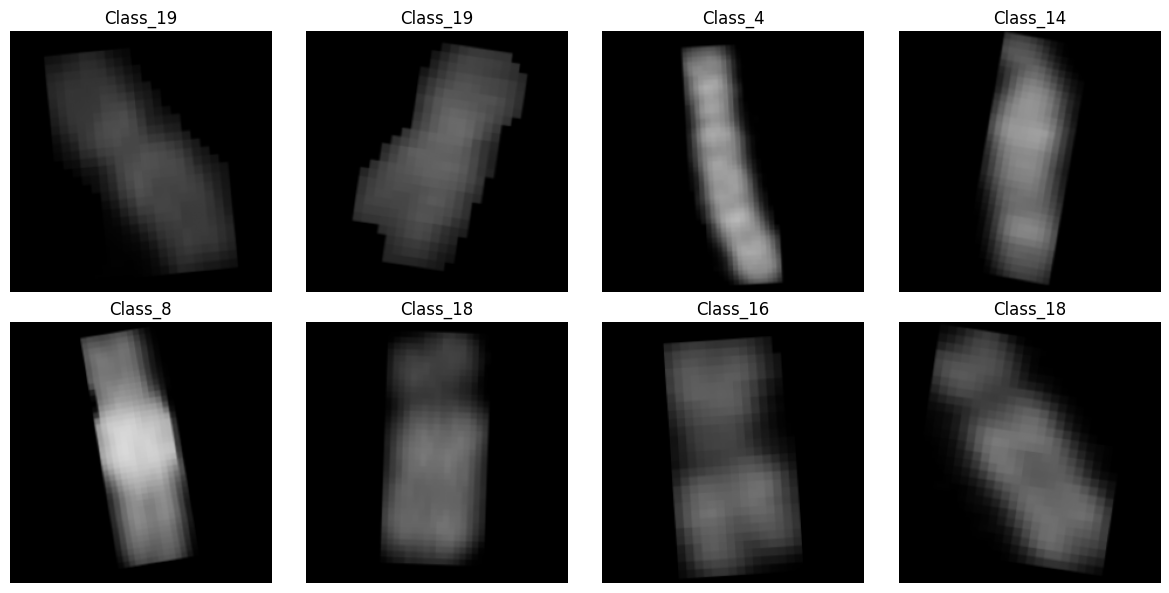

In [68]:
# CELL 33 - Check actual training samples

import matplotlib.pyplot as plt

# Create label mapping directly from your existing classes
index_to_class = {
    i: class_name
    for i, class_name in enumerate(classes)
}

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].numpy())

    label_id = int(labels[i].numpy())

    plt.title(index_to_class[label_id])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
# CELL 34 - Check training label distribution

from collections import Counter

label_counts = Counter(train_y)

print("Training label distribution:\n")

for i in range(NUM_CLASSES):
    print(
        i,
        index_to_class[i],
        ":",
        label_counts[i]
    )

Training label distribution:

0 Class_1 : 167
1 Class_2 : 167
2 Class_3 : 167
3 Class_4 : 166
4 Class_5 : 167
5 Class_6 : 167
6 Class_7 : 166
7 Class_8 : 167
8 Class_9 : 166
9 Class_10 : 167
10 Class_11 : 166
11 Class_12 : 167
12 Class_13 : 167
13 Class_14 : 167
14 Class_15 : 166
15 Class_16 : 166
16 Class_17 : 167
17 Class_18 : 166
18 Class_19 : 166
19 Class_20 : 167
20 Class_21 : 167
21 Class_22 : 166
22 Class_X : 135
23 Class_Y : 31


In [70]:
# CELL 35 - Check validation label distribution

val_counts = Counter(val_y)

print("Validation label distribution:\n")

for i in range(NUM_CLASSES):
    print(
        i,
        index_to_class[i],
        ":",
        val_counts[i]
    )

Validation label distribution:

0 Class_1 : 36
1 Class_2 : 35
2 Class_3 : 36
3 Class_4 : 36
4 Class_5 : 35
5 Class_6 : 36
6 Class_7 : 36
7 Class_8 : 35
8 Class_9 : 36
9 Class_10 : 36
10 Class_11 : 36
11 Class_12 : 35
12 Class_13 : 35
13 Class_14 : 35
14 Class_15 : 36
15 Class_16 : 36
16 Class_17 : 36
17 Class_18 : 36
18 Class_19 : 36
19 Class_20 : 35
20 Class_21 : 36
21 Class_22 : 36
22 Class_X : 29
23 Class_Y : 7


In [71]:
# CELL 36 - Check current dataset

images, labels = next(iter(train_ds))

print("Shape:", images.shape)
print("Dtype:", images.dtype)
print("Min:", tf.reduce_min(images).numpy())
print("Max:", tf.reduce_max(images).numpy())
print("Labels:", labels[:10].numpy())

Shape: (32, 224, 224, 3)
Dtype: <dtype: 'float32'>
Min: 0.0
Max: 0.9960785
Labels: [18  3  0  3 15  0 20 22 22  8]


In [72]:
# CELL 37 - ResNet50 preprocessing

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_resnet(images, labels):
    # Current images are [0, 1]
    images = images * 255.0

    # ResNet50 ImageNet preprocessing
    images = preprocess_input(images)

    return images, labels


train_resnet = train_ds.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

val_resnet = val_ds.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

test_resnet = test_ds.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
)

train_resnet = train_resnet.prefetch(AUTOTUNE)
val_resnet = val_resnet.prefetch(AUTOTUNE)
test_resnet = test_resnet.prefetch(AUTOTUNE)

print("ResNet preprocessing pipeline created.")

ResNet preprocessing pipeline created.


In [73]:
# CELL 38 - Verify ResNet preprocessing

images, labels = next(iter(train_resnet))

print("Shape :", images.shape)
print("Dtype :", images.dtype)
print("Min   :", tf.reduce_min(images).numpy())
print("Max   :", tf.reduce_max(images).numpy())
print("Labels:", labels[:10].numpy())

Shape : (32, 224, 224, 3)
Dtype : <dtype: 'float32'>
Min   : -123.68
Max   : 149.061
Labels: [16  4 22 12 21 20  8 22 19  1]


In [74]:
# CELL 39 - Create ResNet50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

NUM_CLASSES = 24

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

resnet_model = Model(inputs, outputs)

print("Model created.")

Model created.


In [75]:
# CELL 40 - Parameter summary

resnet_model.summary()

print("\nTotal parameters     :", resnet_model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.size(v).numpy()
        for v in resnet_model.trainable_variables
    )
)
print(
    "Non-trainable       :",
    sum(
        tf.size(v).numpy()
        for v in resnet_model.non_trainable_variables
    )
)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │        49,176 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,636,888 (90.17 MB)

 Trainable params: 49,176 (192.09 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total parameters     : 23636888
Trainable parameters: 49176
Non-trainable       : 23587714


In [76]:
# CELL 41 - Compile ResNet50

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [77]:
# CELL 42 - Stage 1 training

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/resnet50_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_stage1 = resnet_model.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.0726 - loss: 3.4895
Epoch 1: val_accuracy improved from None to 0.09501, saving model to /content/resnet50_stage1_best.keras

Epoch 1: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 476ms/step - accuracy: 0.0814 - loss: 3.2983 - val_accuracy: 0.0950 - val_loss: 2.9188 - learning_rate: 1.0000e-04
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.1318 - loss: 2.9754
Epoch 2: val_accuracy improved from 0.09501 to 0.15956, saving model to /content/resnet50_stage1_best.keras

Epoch 2: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 419ms/step - accuracy: 0.1363 - loss: 2.9085 - val_accuracy: 0.1596 - val_loss: 2.7305 - learning_rate: 1.0000e-04
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.1531 - loss: 2.7561
Epoch 3: val_accuracy improved from 0.15956 to 0.16931, saving model to /content/resnet5

In [78]:
# CELL 43 - Enable fine-tuning

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Trainable layers:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

print("\nTotal trainable variables:",
      len(resnet_model.trainable_variables))

Trainable layers:
conv5_block1_1_relu
conv5_block1_2_conv
conv5_block1_2_bn
conv5_block1_2_relu
conv5_block1_0_conv
conv5_block1_3_conv
conv5_block1_0_bn
conv5_block1_3_bn
conv5_block1_add
conv5_block1_out
conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out

Total trainable variables: 38


In [79]:
# CELL 44 - Recompile for fine-tuning

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")

Fine-tuning model compiled.


In [81]:
# CELL 45 - Fine-tuning with class weights

history_stage2 = resnet_model.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.2584 - loss: 2.3485
Epoch 1: val_accuracy improved from 0.23386 to 0.31060, saving model to /content/resnet50_stage1_best.keras

Epoch 1: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 536ms/step - accuracy: 0.2819 - loss: 2.2367 - val_accuracy: 0.3106 - val_loss: 2.1990 - learning_rate: 1.0000e-05
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.3483 - loss: 2.0052
Epoch 2: val_accuracy improved from 0.31060 to 0.35323, saving model to /content/resnet50_stage1_best.keras

Epoch 2: finished saving model to /content/resnet50_stage1_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 52s 427ms/step - accuracy: 0.3654 - loss: 1.9449 - val_accuracy: 0.3532 - val_loss: 1.9979 - learning_rate: 1.0000e-05
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.4202 - loss: 1.7889
Epoch 3: val_accuracy improved from 0.35323 to 0.40682, saving model to /content/r

In [82]:
# TEST SET EVALUATION

from tensorflow.keras.models import load_model

best_model = load_model("/content/resnet50_stage1_best.keras")

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print("\n" + "="*50)
print("TEST RESULTS")
print("="*50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.0438 - loss: 3.7543

TEST RESULTS
Test Loss     : 3.7543
Test Accuracy : 4.38%


In [83]:
# CLASSIFICATION REPORT

import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=3
))

              precision    recall  f1-score   support

     Class_1      0.000     0.000     0.000        35
     Class_2      0.000     0.000     0.000        36
     Class_3      0.000     0.000     0.000        35
     Class_4      0.000     0.000     0.000        36
     Class_5      0.000     0.000     0.000        36
     Class_6      0.000     0.000     0.000        35
     Class_7      0.000     0.000     0.000        36
     Class_8      0.000     0.000     0.000        36
     Class_9      0.044     1.000     0.084        36
    Class_10      0.000     0.000     0.000        35
    Class_11      0.000     0.000     0.000        36
    Class_12      0.000     0.000     0.000        36
    Class_13      0.000     0.000     0.000        36
    Class_14      0.000     0.000     0.000        36
    Class_15      0.000     0.000     0.000        36
    Class_16      0.000     0.000     0.000        36
    Class_17      0.000     0.000     0.000        35
    Class_18      0.000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1400x1400 with 0 Axes>

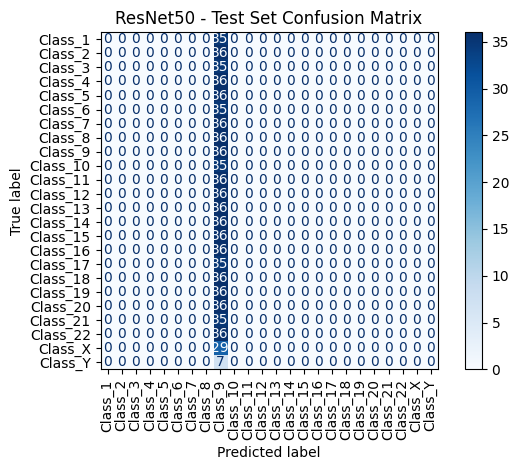

In [84]:
# CONFUSION MATRIX

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("ResNet50 - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [88]:
# CELL C - Compare dataset image statistics

def check_dataset_stats(ds, name):
    images, labels = next(iter(ds))

    print(f"\n{name}")
    print("=" * 45)
    print("Image shape :", images.shape)
    print("Image dtype :", images.dtype)
    print("Min value  :", float(tf.reduce_min(images)))
    print("Max value  :", float(tf.reduce_max(images)))
    print("Mean value :", float(tf.reduce_mean(images)))
    print("Std value  :", float(tf.math.reduce_std(images)))
    print("Labels     :", labels[:10].numpy())


check_dataset_stats(train_ds, "TRAIN")
check_dataset_stats(val_ds, "VALIDATION")
check_dataset_stats(test_ds, "TEST")


TRAIN
Image shape : (32, 224, 224, 3)
Image dtype : <dtype: 'float32'>
Min value  : 0.0
Max value  : 0.9960784912109375
Mean value : 0.12246955931186676
Std value  : 0.19177059829235077
Labels     : [ 8 14  7  1 20  5  2  4 12 20]

VALIDATION
Image shape : (32, 224, 224, 3)
Image dtype : <dtype: 'float32'>
Min value  : 0.0
Max value  : 0.9803921580314636
Mean value : 0.11302699893712997
Std value  : 0.18023037910461426
Labels     : [ 6  4  8  8  9 15 17  8 18  6]

TEST
Image shape : (32, 224, 224, 3)
Image dtype : <dtype: 'float32'>
Min value  : 0.0
Max value  : 0.9686274528503418
Mean value : 0.11141141504049301
Std value  : 0.17335374653339386
Labels     : [ 7 20 13 16 20 19 16 11 20 21]


In [96]:
# CELL D2 - Compare predictions on TRAIN / VALIDATION / TEST

import numpy as np

def check_dataset(model, dataset, name):

    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = np.mean(y_true == y_pred)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nPrediction distribution:")

    counts = np.bincount(y_pred, minlength=24)

    for i in range(24):
        print(f"{i:2d} -> {classes[i]:8s}: {counts[i]}")

    return y_true, y_pred


train_true, train_pred = check_dataset(
    model,
    train_ds,
    "TRAIN"
)

val_true, val_pred = check_dataset(
    model,
    val_ds,
    "VALIDATION"
)

test_true, test_pred = check_dataset(
    model,
    test_ds,
    "TEST"
)


TRAIN
Accuracy: 4.33 %

Prediction distribution:
 0 -> Class_1 : 0
 1 -> Class_2 : 0
 2 -> Class_3 : 0
 3 -> Class_4 : 0
 4 -> Class_5 : 0
 5 -> Class_6 : 0
 6 -> Class_7 : 0
 7 -> Class_8 : 0
 8 -> Class_9 : 3831
 9 -> Class_10: 0
10 -> Class_11: 0
11 -> Class_12: 0
12 -> Class_13: 0
13 -> Class_14: 0
14 -> Class_15: 0
15 -> Class_16: 0
16 -> Class_17: 0
17 -> Class_18: 0
18 -> Class_19: 0
19 -> Class_20: 0
20 -> Class_21: 0
21 -> Class_22: 0
22 -> Class_X : 0
23 -> Class_Y : 0

VALIDATION
Accuracy: 4.38 %

Prediction distribution:
 0 -> Class_1 : 0
 1 -> Class_2 : 0
 2 -> Class_3 : 0
 3 -> Class_4 : 0
 4 -> Class_5 : 0
 5 -> Class_6 : 0
 6 -> Class_7 : 0
 7 -> Class_8 : 0
 8 -> Class_9 : 821
 9 -> Class_10: 0
10 -> Class_11: 0
11 -> Class_12: 0
12 -> Class_13: 0
13 -> Class_14: 0
14 -> Class_15: 0
15 -> Class_16: 0
16 -> Class_17: 0
17 -> Class_18: 0
18 -> Class_19: 0
19 -> Class_20: 0
20 -> Class_21: 0
21 -> Class_22: 0
22 -> Class_X : 0
23 -> Class_Y : 0

TEST
Accuracy: 4.38 %

Pr

In [97]:
# CELL D3 - Check whether the loaded model weights are collapsed

import numpy as np

print("=" * 60)
print("MODEL WEIGHT DIAGNOSTIC")
print("=" * 60)

for layer in model.layers:

    weights = layer.get_weights()

    if len(weights) > 0:

        print("\nLayer:", layer.name)

        for j, w in enumerate(weights):

            print(
                "  Weight", j,
                "shape:", w.shape,
                "mean:", round(float(np.mean(w)), 6),
                "std:", round(float(np.std(w)), 6),
                "min:", round(float(np.min(w)), 6),
                "max:", round(float(np.max(w)), 6)
            )

MODEL WEIGHT DIAGNOSTIC

Layer: resnet50
  Weight 0 shape: (7, 7, 3, 64) mean: -0.00049 std: 0.111119 min: -0.671024 max: 0.704324
  Weight 1 shape: (64,) mean: 0.0 std: 0.0 min: -0.0 max: 0.0
  Weight 2 shape: (64,) mean: 1.222852 std: 0.464795 min: 0.512643 max: 2.668587
  Weight 3 shape: (64,) mean: 1.021979 std: 1.895417 min: -2.653984 max: 6.353635
  Weight 4 shape: (64,) mean: 0.040491 std: 1.003265 min: -3.537402 max: 3.334259
  Weight 5 shape: (64,) mean: 8680.625977 std: 13554.542969 min: 184.107849 max: 83614.734375
  Weight 6 shape: (1, 1, 64, 64) mean: -0.006269 std: 0.071447 min: -0.717496 max: 0.392186
  Weight 7 shape: (64,) mean: 0.0 std: 0.0 min: 0.0 max: 0.0
  Weight 8 shape: (64,) mean: 1.183257 std: 0.373722 min: 0.509218 max: 2.066087
  Weight 9 shape: (64,) mean: -0.006573 std: 1.1673 min: -2.410869 max: 3.607542
  Weight 10 shape: (64,) mean: -1.42235 std: 2.102663 min: -4.624998 max: 7.615551
  Weight 11 shape: (64,) mean: 1.370063 std: 1.447837 min: 0.052204 ma

In [98]:
# CELL D4 - Inspect only the final classification layer

print("=" * 60)
print("FINAL LAYERS")
print("=" * 60)

for layer in model.layers[-5:]:
    print("\nLayer name :", layer.name)
    print("Layer type :", type(layer).__name__)
    print("Output shape:", layer.output_shape if hasattr(layer, "output_shape") else "N/A")

    weights = layer.get_weights()

    if len(weights) > 0:
        for i, w in enumerate(weights):
            print(
                f"Weight {i}: shape={w.shape}, "
                f"mean={np.mean(w):.6f}, "
                f"std={np.std(w):.6f}, "
                f"min={np.min(w):.6f}, "
                f"max={np.max(w):.6f}"
            )

FINAL LAYERS

Layer name : input_layer_7
Layer type : InputLayer
Output shape: N/A

Layer name : resnet50
Layer type : Functional
Output shape: (None, 7, 7, 2048)
Weight 0: shape=(7, 7, 3, 64), mean=-0.000490, std=0.111119, min=-0.671024, max=0.704324
Weight 1: shape=(64,), mean=0.000000, std=0.000000, min=-0.000000, max=0.000000
Weight 2: shape=(64,), mean=1.222852, std=0.464795, min=0.512643, max=2.668587
Weight 3: shape=(64,), mean=1.021979, std=1.895417, min=-2.653984, max=6.353635
Weight 4: shape=(64,), mean=0.040491, std=1.003265, min=-3.537402, max=3.334259
Weight 5: shape=(64,), mean=8680.625977, std=13554.542969, min=184.107849, max=83614.734375
Weight 6: shape=(1, 1, 64, 64), mean=-0.006269, std=0.071447, min=-0.717496, max=0.392186
Weight 7: shape=(64,), mean=0.000000, std=0.000000, min=0.000000, max=0.000000
Weight 8: shape=(64,), mean=1.183257, std=0.373722, min=0.509218, max=2.066087
Weight 9: shape=(64,), mean=-0.006573, std=1.167300, min=-2.410869, max=3.607542
Weight 1

In [99]:
import numpy as np
import tensorflow as tf

print("Model output:", model.output_shape)

# Get one batch from each dataset
for name, ds in [
    ("TRAIN", train_ds),
    ("VALIDATION", val_ds),
    ("TEST", test_ds)
]:
    images, labels = next(iter(ds))

    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("True labels :", labels.numpy()[:20])
    print("Pred labels :", pred_classes[:20])

    print("Prediction counts:",
          np.bincount(pred_classes, minlength=24))

    print("Prediction confidence:",
          np.max(preds, axis=1)[:10])

Model output: (None, 24)

TRAIN
True labels : [ 5 17 11 23 16 20  6 19 19 17  8  9 12  0  8  9 22  9  0 20]
Pred labels : [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
Prediction counts: [ 0  0  0  0  0  0  0  0 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Prediction confidence: [0.2003885  0.19378589 0.19730595 0.19657509 0.19660719 0.19438025
 0.20736511 0.19542108 0.19422105 0.19492888]

VALIDATION
True labels : [ 6  4  8  8  9 15 17  8 18  6 10 22  2 20 11 22 18 13 20 12]
Pred labels : [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
Prediction counts: [ 0  0  0  0  0  0  0  0 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Prediction confidence: [0.19430846 0.1967922  0.1950669  0.1950412  0.19614829 0.19337927
 0.19238386 0.1964992  0.19560213 0.19682689]

TEST
True labels : [ 7 20 13 16 20 19 16 11 20 21  7  3 10  7  0 19 16 13  5 21]
Pred labels : [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
Prediction counts: [ 0  0  0  0  0  0  0  0 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Pre

In [100]:
import numpy as np
import tensorflow as tf

print("MODEL OUTPUT:", model.output_shape)

# Take one batch from each dataset
for name, ds in [("TRAIN", train_ds), ("VALIDATION", val_ds), ("TEST", test_ds)]:

    images, labels = next(iter(ds))

    preds = model.predict(images, verbose=0)

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("Input mean:", np.mean(images.numpy()))
    print("Input std :", np.std(images.numpy()))

    print("Labels:", labels.numpy()[:20])

    print("Pred shape:", preds.shape)

    print("First prediction:", preds[0])

    print("Prediction sum:", np.sum(preds[0]))

    print("Predicted classes:", np.argmax(preds, axis=1)[:20])

    print("Prediction mean per class:")
    print(np.mean(preds, axis=0))

MODEL OUTPUT: (None, 24)

TRAIN
Input mean: 0.109173186
Input std : 0.17282929
Labels: [ 3 19  6  8 17 22 20 12 16  6 15  6  2  6  9 16 14 20  7  4]
Pred shape: (32, 24)
First prediction: [0.16595861 0.10494295 0.05471925 0.11568575 0.02311376 0.0290388
 0.01878381 0.01314308 0.19706255 0.01714813 0.02558406 0.00964887
 0.01517935 0.06127767 0.00486004 0.02170713 0.00963813 0.00310847
 0.05795025 0.0130688  0.00692475 0.0139296  0.01103837 0.00648757]
Prediction sum: 0.9999997
Predicted classes: [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
Prediction mean per class:
[0.16486664 0.10458267 0.05451509 0.11666988 0.02317303 0.02913125
 0.01889667 0.0131063  0.19709058 0.01719558 0.0260139  0.00959442
 0.01524189 0.06203866 0.00482446 0.02173735 0.00967109 0.00309761
 0.05762095 0.01301852 0.00678864 0.01378997 0.0108582  0.00647659]

VALIDATION
Input mean: 0.113027
Input std : 0.18023042
Labels: [ 6  4  8  8  9 15 17  8 18  6 10 22  2 20 11 22 18 13 20 12]
Pred shape: (32, 24)
First predicti

In [101]:
# ============================================================
# CHECK WHETHER RESNET FEATURES CHANGE BETWEEN IMAGES
# ============================================================

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("global_average_pooling2d_1").output
)

images, labels = next(iter(train_ds))

features = feature_model.predict(images, verbose=0)

print("Feature shape:", features.shape)

print("Feature mean:", np.mean(features))
print("Feature std :", np.std(features))

# Compare feature vectors
for i in range(5):
    print(
        f"Image {i}: mean={np.mean(features[i]):.6f}, "
        f"std={np.std(features[i]):.6f}, "
        f"min={np.min(features[i]):.6f}, "
        f"max={np.max(features[i]):.6f}"
    )

# Difference between feature vectors
print("\nFeature differences:")

for i in range(1, 5):
    diff = np.mean(np.abs(features[0] - features[i]))
    print(f"Image 0 vs Image {i}: {diff:.10f}")

Feature shape: (32, 2048)
Feature mean: 0.16746786
Feature std : 0.7129077
Image 0: mean=0.167089, std=0.712204, min=0.000000, max=20.243412
Image 1: mean=0.168369, std=0.712938, min=0.000000, max=20.243528
Image 2: mean=0.168100, std=0.716997, min=0.000000, max=20.330015
Image 3: mean=0.166864, std=0.711167, min=0.000000, max=20.275295
Image 4: mean=0.167325, std=0.713278, min=0.000000, max=20.297253

Feature differences:
Image 0 vs Image 1: 0.0035662991
Image 0 vs Image 2: 0.0077420915
Image 0 vs Image 3: 0.0048212083
Image 0 vs Image 4: 0.0058916435


In [102]:
# ============================================================
# CHECK FINAL CLASSIFIER
# ============================================================

classifier = model.get_layer("dense_1")

weights, bias = classifier.get_weights()

print("Classifier weights shape:", weights.shape)
print("Classifier bias shape:", bias.shape)

print("\nBias values:")
for i in range(24):
    print(f"Class {i:2d}: {bias[i]:.8f}")

print("\nBias argmax:", np.argmax(bias))
print("Bias max   :", np.max(bias))
print("Bias min   :", np.min(bias))

# Calculate average classifier score for the current batch
images, labels = next(iter(train_ds))

features = feature_model.predict(images, verbose=0)

logits = np.matmul(features, weights) + bias

print("\nLOGIT CHECK")
print("Logits shape:", logits.shape)

print("\nMean logit per class:")
mean_logits = np.mean(logits, axis=0)

for i in range(24):
    print(f"Class {i:2d}: {mean_logits[i]:.6f}")

print("\nHighest mean-logit class:", np.argmax(mean_logits))

Classifier weights shape: (2048, 24)
Classifier bias shape: (24,)

Bias values:
Class  0: -0.00729460
Class  1: -0.00014934
Class  2: -0.00762107
Class  3: 0.00300031
Class  4: -0.00456726
Class  5: -0.00294249
Class  6: -0.00058477
Class  7: -0.00389360
Class  8: 0.00258944
Class  9: 0.00263001
Class 10: -0.00300675
Class 11: -0.00164815
Class 12: -0.00701652
Class 13: 0.00304647
Class 14: 0.00383901
Class 15: 0.00114573
Class 16: 0.00580272
Class 17: -0.00043395
Class 18: 0.00923675
Class 19: 0.01118907
Class 20: -0.00015148
Class 21: 0.01110371
Class 22: -0.00139509
Class 23: -0.00804390

Bias argmax: 19
Bias max   : 0.011189066
Bias min   : -0.008043899

LOGIT CHECK
Logits shape: (32, 24)

Mean logit per class:
Class  0: 0.735156
Class  1: 0.271588
Class  2: -0.373540
Class  3: 0.387641
Class  4: -1.226508
Class  5: -1.003403
Class  6: -1.433006
Class  7: -1.798225
Class  8: 0.909654
Class  9: -1.527738
Class 10: -1.118695
Class 11: -2.110060
Class 12: -1.644574
Class 13: -0.246027

In [104]:
# Get a batch
images, labels = next(iter(train_ds))

# Extract ResNet features
features = resnet50(images, training=False)

print("Input:", images.shape)
print("Features:", features.shape)

# Compare images
for i in range(5):
    print(
        i,
        "input mean =", tf.reduce_mean(images[i]).numpy(),
        "input std  =", tf.math.reduce_std(images[i]).numpy(),
        "feature mean =", tf.reduce_mean(features[i]).numpy(),
        "feature std =", tf.math.reduce_std(features[i]).numpy()
    )

# Difference between feature vectors
for i in range(1, 5):
    diff = tf.reduce_mean(
        tf.abs(features[0] - features[i])
    )
    print("Feature difference 0 vs", i, ":", diff.numpy())

NameError: name 'resnet50' is not defined

#Save trained model

In [90]:
# SAVE TRAINED RESNET50 MODEL TO GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [91]:
import os
import shutil

source_model = "/content/resnet50_stage1_best.keras"

drive_folder = "/content/drive/MyDrive/Chromosome_Project"

os.makedirs(drive_folder, exist_ok=True)

destination_model = os.path.join(
    drive_folder,
    "resnet50_stage1_best.keras"
)

shutil.copy2(source_model, destination_model)

print("Model saved successfully!")
print("Location:", destination_model)
print("Size:", os.path.getsize(destination_model) / (1024 * 1024), "MB")

Model saved successfully!
Location: /content/drive/MyDrive/Chromosome_Project/resnet50_stage1_best.keras
Size: 201.44188690185547 MB


#Save class mapping

In [92]:
import json

class_mapping = {
    str(i): classes[i]
    for i in range(len(classes))
}

mapping_path = os.path.join(
    drive_folder,
    "class_mapping.json"
)

with open(mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Class mapping saved:")
print(mapping_path)

Class mapping saved:
/content/drive/MyDrive/Chromosome_Project/class_mapping.json


#Save training hostory

In [94]:
# CELL S4 - Verify saved model

import os

model_path = "/content/drive/MyDrive/Chromosome_Project/resnet50_stage1_best.keras"

if os.path.exists(model_path):
    print("MODEL FOUND")
    print("Path:", model_path)
    print(
        "Size:",
        round(os.path.getsize(model_path) / (1024 * 1024), 2),
        "MB"
    )
else:
    print("MODEL NOT FOUND")

MODEL FOUND
Path: /content/drive/MyDrive/Chromosome_Project/resnet50_stage1_best.keras
Size: 201.44 MB


#Load saved model

In [95]:
# CELL D1 - Load saved ResNet50

import tensorflow as tf

model_path = "/content/drive/MyDrive/Chromosome_Project/resnet50_stage1_best.keras"

model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

Model loaded successfully
Input shape : (None, 224, 224, 3)
Output shape: (None, 24)
